# Evaluation Results Analysis

This notebook loads the accumulated evaluation CSV and generates plots comparing all methods for BER, FER, and average messages.

## 1. Import Required Libraries
Import pandas, matplotlib, seaborn, and any other required libraries for data analysis and plotting.

In [29]:
import os
from glob import glob

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

## 2. Load Evaluation Results
Load the accumulated CSV file (e.g., 'wran_full_accumulated.csv') containing evaluation results for all methods.

In [30]:
# Load and combine quick + full/legacy evaluation data when available
quick_pattern = "results_mi_quick_fe60_mf3000/wran_mi_quick_*.csv"

# New full-eval location from SLURM bundle
full_accum_candidates = [
    "results_full_fe300_mf10000/wran_full_accumulated.csv",
    "wran_full_accumulated.csv",
]
full_run_pattern = "results_full_fe300_mf10000/wran_full_*.csv"

# Legacy/alternate locations already present in this repo
legacy_exact_files = [
    "results/latest_berfer.csv",
    "results/eval_deep_z2_resume_live.csv",
    "results/eval_deep_z2_10k.csv",
    "results/eval_deep_z2_resume_live_z1_only.csv",
    "results/eval_deep_z2_10k_z1_only.csv",
]
legacy_glob_patterns = [
    "results/eval_*berfer*.csv",
    "../../../deep_reldec_z1/wran/results/*.csv",
    "../../../deep_reldec_z2/wran/results/*.csv",
]

frames = []
loaded_files = []


def add_csv(path):
    if not os.path.exists(path):
        return
    try:
        df_part = pd.read_csv(path)
    except Exception as exc:
        print(f"[skip] {path}: {exc}")
        return
    if "method" not in df_part.columns:
        return
    df_part["source_file"] = path
    frames.append(df_part)
    loaded_files.append(path)


# Quick MI CSV(s)
for path in sorted(glob(quick_pattern)):
    add_csv(path)

# Full accumulated CSV if present
for candidate in full_accum_candidates:
    if os.path.exists(candidate):
        add_csv(candidate)
        break

# Full per-run CSVs
for path in sorted(glob(full_run_pattern)):
    if path.endswith("wran_full_accumulated.csv"):
        continue
    add_csv(path)

# Legacy exact + wildcard CSVs
for path in legacy_exact_files:
    add_csv(path)
for pattern in legacy_glob_patterns:
    for path in sorted(glob(pattern)):
        add_csv(path)

if not frames:
    raise FileNotFoundError(
        "No evaluation CSVs found in quick/full/legacy result locations."
    )

df = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(loaded_files)} CSV file(s), combined rows: {len(df)}")
print("Sample loaded files:")
for p in loaded_files[:12]:
    print(f"  - {p}")
if len(loaded_files) > 12:
    print(f"  ... and {len(loaded_files) - 12} more")

display(df.head())

Loaded 15 CSV file(s), combined rows: 219
Sample loaded files:
  - results_mi_quick_fe60_mf3000/wran_mi_quick_20260423_015257.csv
  - results/latest_berfer.csv
  - results/eval_deep_z2_resume_live.csv
  - results/eval_deep_z2_10k.csv
  - results/eval_deep_z2_resume_live_z1_only.csv
  - results/eval_deep_z2_10k_z1_only.csv
  - results/eval_final_berfer_20260325_021320.csv
  - results/eval_periodic_berfer_20260325_002118.csv
  - ../../../deep_reldec_z1/wran/results/eval_deep_z2_10k_z1_only.csv
  - ../../../deep_reldec_z1/wran/results/eval_deep_z2_resume_live_z1_only.csv
  - ../../../deep_reldec_z2/wran/results/eval_deep_z2_10k.csv
  - ../../../deep_reldec_z2/wran/results/eval_deep_z2_10k_z1_only.csv
  ... and 3 more


,method,snr_db,frames,bit_errors,frame_errors,ber,fer,avg_messages,avg_iterations,converged_frames,code,matrix_csv,code_rate,i_max,target_frame_errors,max_frames,all_zero_only,source_file
0,mi_naive_z2,1.0,60,1904,60,0.082639,1.000000,6480.000000,5.000000,0,wran,RELDEC/matrices/WRAN_irreg_384_256.csv,0.666667,5,60,3000,True,results_mi_quick_fe60_mf3000/wran_mi_quick_202...
1,mi_dqn_z2,1.0,60,1770,60,0.076823,1.000000,6480.000000,5.000000,0,wran,RELDEC/matrices/WRAN_irreg_384_256.csv,0.666667,5,60,3000,True,results_mi_quick_fe60_mf3000/wran_mi_quick_202...
2,mi_naive_z2,2.0,90,1042,60,0.030150,0.666667,6048.000000,4.666667,30,wran,RELDEC/matrices/WRAN_irreg_384_256.csv,0.666667,5,60,3000,True,results_mi_quick_fe60_mf3000/wran_mi_quick_202...
3,mi_dqn_z2,2.0,100,953,60,0.024818,0.600000,5676.480000,4.380000,40,wran,RELDEC/matrices/WRAN_irreg_384_256.csv,0.666667,5,60,3000,True,results_mi_quick_fe60_mf3000/wran_mi_quick_202...
4,mi_naive_z2,3.0,871,744,60,0.002224,0.068886,3804.675086,2.935706,811,wran,RELDEC/matrices/WRAN_irreg_384_256.csv,0.666667,5,60,3000,True,results_mi_quick_fe60_mf3000/wran_mi_quick_202...


## 3. Preprocess and Merge Data
Clean and preprocess the loaded data. Ensure all methods are included, handle missing values, and prepare the data for plotting.

In [31]:
# Normalize numeric columns used by plots
for col in ["snr_db", "ber", "fer", "avg_messages", "target_frame_errors", "max_frames"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep rows with complete plotting data
df = df.dropna(subset=["snr_db", "ber", "fer", "avg_messages", "method"])

# Deduplicate repeated rows from overlapping CSVs
dedupe_keys = [
    "method",
    "snr_db",
    "code",
    "matrix_csv",
    "target_frame_errors",
    "max_frames",
    "all_zero_only",
]
available_keys = [k for k in dedupe_keys if k in df.columns]
if available_keys:
    df = df.sort_values(["method", "snr_db"]).drop_duplicates(subset=available_keys, keep="last")
else:
    df = df.sort_values(["method", "snr_db"]).drop_duplicates()

# Build a comparison dataframe with one best row per method+snr.
# Preference: larger max_frames, then larger target_frame_errors.
sort_cols = ["method", "snr_db"]
ascending = [True, True]
if "max_frames" in df.columns:
    sort_cols.append("max_frames")
    ascending.append(False)
if "target_frame_errors" in df.columns:
    sort_cols.append("target_frame_errors")
    ascending.append(False)

plot_df = (
    df.sort_values(sort_cols, ascending=ascending)
      .drop_duplicates(subset=["method", "snr_db"], keep="first")
      .sort_values(["method", "snr_db"])
)

methods = sorted(plot_df["method"].unique())
expected_methods = [
    "flooding",
    "random",
    "round_robin",
    "reldec",
    "mi_naive_z2",
    "deep_reldec_z1",
    "deep_reldec_z2",
    "mi_dqn_z2",
]
missing_methods = [m for m in expected_methods if m not in methods]

print(f"Methods found ({len(methods)}): {methods}")
if missing_methods:
    print(f"Missing methods in current data: {missing_methods}")
else:
    print("All expected methods are present.")

if "target_frame_errors" in plot_df.columns and "max_frames" in plot_df.columns:
    combos = (
        plot_df[["method", "target_frame_errors", "max_frames"]]
        .drop_duplicates()
        .sort_values(["method", "target_frame_errors", "max_frames"])
    )
    print("Method coverage by (target_frame_errors, max_frames):")
    display(combos)

print(f"Rows retained for plotting (one row per method+snr): {len(plot_df)}")

# Keep downstream plotting cells unchanged
df = plot_df

Methods found (8): ['deep_reldec_z1', 'deep_reldec_z2', 'flooding', 'mi_dqn_z2', 'mi_naive_z2', 'random', 'reldec', 'round_robin']
All expected methods are present.
Method coverage by (target_frame_errors, max_frames):


,method,target_frame_errors,max_frames
204,deep_reldec_z1,60,3000
210,deep_reldec_z2,20,4000
190,deep_reldec_z2,60,3000
215,flooding,20,4000
160,flooding,60,3000
115,flooding,300,10000
1,mi_dqn_z2,60,3000
0,mi_naive_z2,60,3000
216,random,20,4000
166,random,60,3000


Rows retained for plotting (one row per method+snr): 56


## 4. Plot BER vs SNR for All Methods
Create a line plot comparing Bit Error Rate (BER) vs SNR (dB) for all evaluated methods.

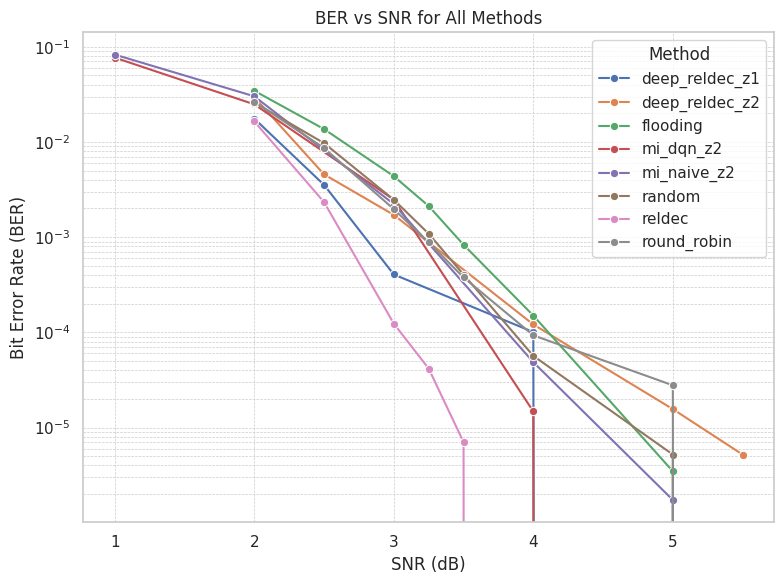

In [32]:
plt.figure(figsize=(8,6))
sns.lineplot(data=df, x='snr_db', y='ber', hue='method', marker='o')
plt.yscale('log')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('BER vs SNR for All Methods')
plt.legend(title='Method')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

## 5. Plot FER vs SNR for All Methods
Create a line plot comparing Frame Error Rate (FER) vs SNR (dB) for all evaluated methods.

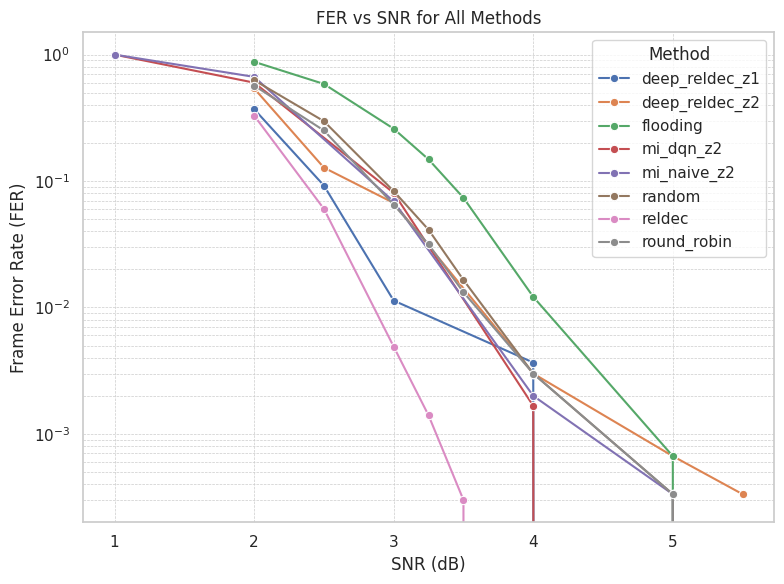

In [33]:
plt.figure(figsize=(8,6))
sns.lineplot(data=df, x='snr_db', y='fer', hue='method', marker='o')
plt.yscale('log')
plt.xlabel('SNR (dB)')
plt.ylabel('Frame Error Rate (FER)')
plt.title('FER vs SNR for All Methods')
plt.legend(title='Method')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

## 6. Plot Average Messages vs SNR for All Methods
Create a line plot comparing the average number of messages vs SNR (dB) for all evaluated methods.

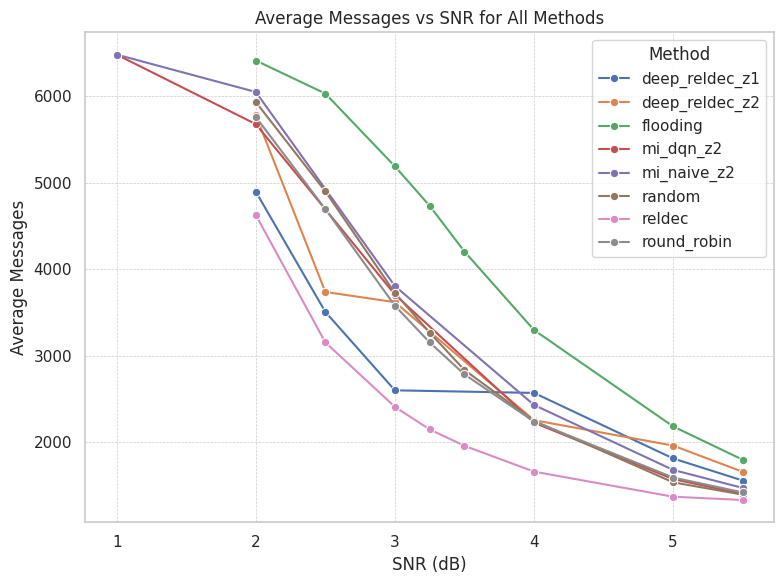

In [34]:
plt.figure(figsize=(8,6))
sns.lineplot(data=df, x='snr_db', y='avg_messages', hue='method', marker='o')
plt.xlabel('SNR (dB)')
plt.ylabel('Average Messages')
plt.title('Average Messages vs SNR for All Methods')
plt.legend(title='Method')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()